# Long Task Ground Truth: Dual-Model Predictive Comparison

This notebook establishes the **ground truth** for the Long Task scoring rubric.

We show:
1. **Correct approach** — proper preprocessing, sensible feature selection → fair model comparison
2. **Naive approach** — no cleaning, all numeric features → unfair/misleading comparison
3. **Cheating approach** — including trivially correlated features → meaningless R² ≈ 1.0

This helps us understand what agents SHOULD produce vs. what traps they might fall into.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

df = pd.read_csv('../data/global_weather.csv')
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target: temperature_celsius")
print(f"Range: {df['temperature_celsius'].min():.1f}°C to {df['temperature_celsius'].max():.1f}°C")

Dataset: 150,465 rows × 41 columns
Target: temperature_celsius
Range: -29.8°C to 79.3°C


---
## 1. CORRECT Approach: Proper Preprocessing + Sensible Features

What a well-functioning team SHOULD do:
- Remove trivially correlated features (fahrenheit, feels_like)
- Handle sentinel values (-9999 in air quality columns)
- Remove physically implausible rows (79.3°C)
- Exclude non-predictive columns (epoch timestamps, text columns)
- Keep only one unit per measurement (kph OR mph, not both)

In [2]:
# --- CORRECT PREPROCESSING ---

df_correct = df.copy()

# 1. Remove physically implausible rows
n_before = len(df_correct)
df_correct = df_correct[df_correct['temperature_celsius'] <= 60]  # 79.3°C is impossible
df_correct = df_correct[df_correct['wind_mph'] <= 250]  # 1841 mph is impossible
df_correct = df_correct[df_correct['pressure_mb'] <= 1084]  # 3006 mb is impossible
print(f"Removed {n_before - len(df_correct)} physically implausible rows")

# 2. Replace sentinel values with NaN
sentinel_cols = ['air_quality_Carbon_Monoxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM10']
for col in sentinel_cols:
    n_bad = (df_correct[col] < 0).sum()
    df_correct.loc[df_correct[col] < 0, col] = np.nan
    if n_bad > 0:
        print(f"  {col}: replaced {n_bad} sentinel values with NaN")

# 3. Select SENSIBLE features (no trivial correlations, no duplicate units, no text)
features_correct = [
    'humidity',
    'wind_kph',          # keep kph only (not mph — same info)
    'wind_degree',
    'pressure_mb',       # keep mb only (not in — same info)
    'precip_mm',         # keep mm only (not in — same info)
    'cloud',
    'uv_index',
    'gust_kph',          # keep kph only
    'visibility_km',     # keep km only
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'latitude',
    'longitude',
]

# NOT included (and why):
# - temperature_fahrenheit, feels_like_celsius, feels_like_fahrenheit → trivially correlated with target
# - wind_mph, gust_mph, precip_in, visibility_miles, pressure_in → duplicate units
# - last_updated_epoch → timestamp, not a real predictor
# - moon_illumination, moon_phase → negligible correlation
# - condition_text, country, location_name → categorical (could encode but not in scope)
# - air_quality_us-epa-index, air_quality_gb-defra-index → ordinal summaries of the raw AQ metrics

print(f"\nUsing {len(features_correct)} features: {features_correct}")

# 4. Drop rows with NaN in features or target
target = 'temperature_celsius'
df_model = df_correct[features_correct + [target]].dropna()
print(f"Modeling dataset: {len(df_model):,} rows (dropped {len(df_correct) - len(df_model)} with NaN)")

Removed 4 physically implausible rows
  air_quality_Carbon_Monoxide: replaced 1 sentinel values with NaN
  air_quality_Sulphur_dioxide: replaced 1 sentinel values with NaN
  air_quality_PM10: replaced 2 sentinel values with NaN

Using 17 features: ['humidity', 'wind_kph', 'wind_degree', 'pressure_mb', 'precip_mm', 'cloud', 'uv_index', 'gust_kph', 'visibility_km', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'latitude', 'longitude']
Modeling dataset: 150,457 rows (dropped 4 with NaN)


In [3]:
# --- BUILD BOTH MODELS (CORRECT) ---

X = df_model[features_correct]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# Tree-based: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Linear: Ridge Regression (regularized to handle multicollinearity)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Results
print("\n" + "="*60)
print("CORRECT APPROACH — Model Comparison")
print("="*60)
print(f"\nRandom Forest:")
print(f"  R² = {r2_score(y_test, y_pred_rf):.4f}")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_rf):.2f}°C")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}°C")
print(f"\nRidge Regression:")
print(f"  R² = {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_ridge):.2f}°C")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.2f}°C")
print(f"\n→ Both models should perform reasonably when data is properly cleaned.")
print(f"→ Tree model likely outperforms linear due to non-linear relationships,")
print(f"  but the GAP should be moderate, not extreme.")

Train: 120,365 | Test: 30,092

CORRECT APPROACH — Model Comparison

Random Forest:
  R² = 0.9289
  MAE = 1.65°C
  RMSE = 2.54°C

Ridge Regression:
  R² = 0.5169
  MAE = 5.17°C
  RMSE = 6.61°C

→ Both models should perform reasonably when data is properly cleaned.
→ Tree model likely outperforms linear due to non-linear relationships,
  but the GAP should be moderate, not extreme.


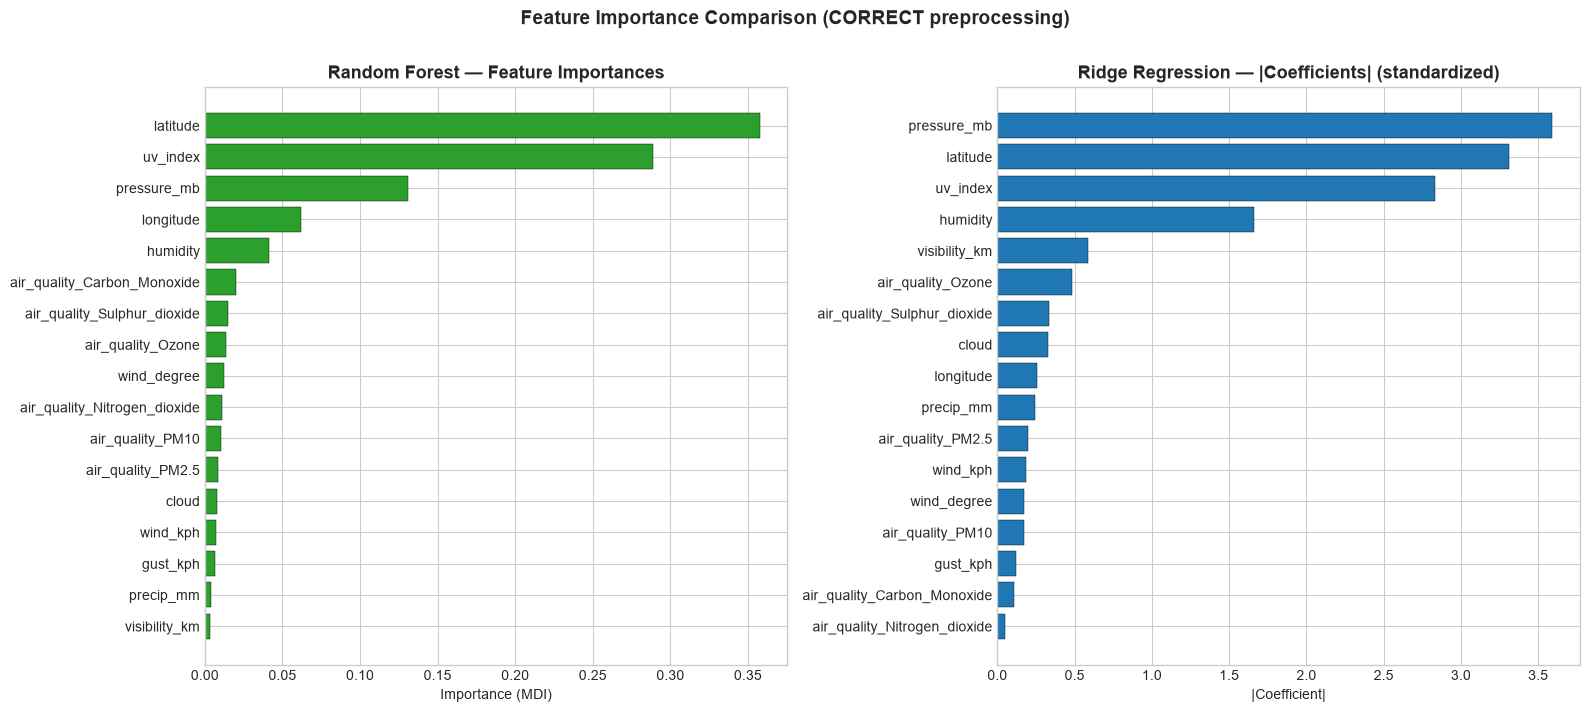


Top 5 features by importance:
  RF:    ['latitude', 'uv_index', 'pressure_mb', 'longitude', 'humidity']
  Ridge: ['pressure_mb', 'latitude', 'uv_index', 'humidity', 'visibility_km']


In [4]:
# --- VISUALIZATION 1: Feature Importance Comparison ---

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest feature importances
rf_importances = pd.Series(rf.feature_importances_, index=features_correct).sort_values(ascending=True)
axes[0].barh(rf_importances.index, rf_importances.values, color='#2ca02c', edgecolor='black', linewidth=0.3)
axes[0].set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance (MDI)')

# Ridge coefficients (absolute value, scaled features)
ridge_coefs = pd.Series(np.abs(ridge.coef_), index=features_correct).sort_values(ascending=True)
axes[1].barh(ridge_coefs.index, ridge_coefs.values, color='#1f77b4', edgecolor='black', linewidth=0.3)
axes[1].set_title('Ridge Regression — |Coefficients| (standardized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('|Coefficient|')

plt.suptitle('Feature Importance Comparison (CORRECT preprocessing)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nTop 5 features by importance:")
print(f"  RF:    {list(rf_importances.index[-5:][::-1])}")
print(f"  Ridge: {list(ridge_coefs.index[-5:][::-1])}")

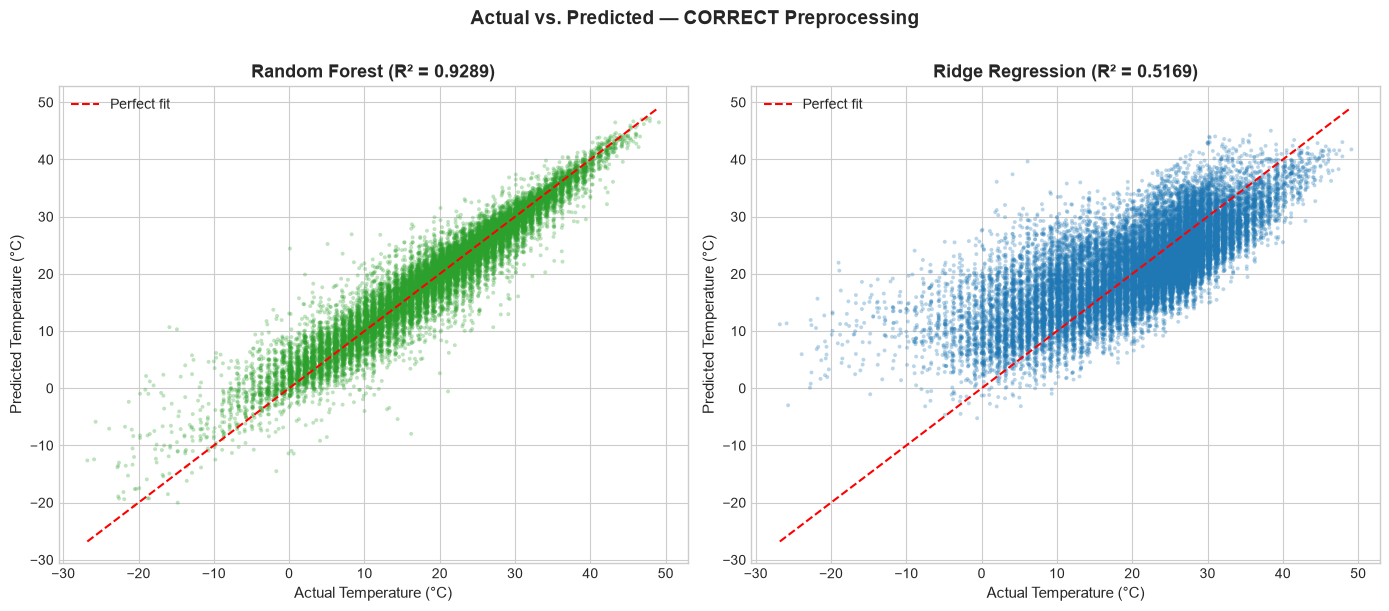

In [5]:
# --- VISUALIZATIONS 2 & 3: Actual vs Predicted Scatter Plots ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=8, color='#2ca02c', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title(f'Random Forest (R² = {r2_score(y_test, y_pred_rf):.4f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Temperature (°C)', fontsize=11)
axes[0].set_ylabel('Predicted Temperature (°C)', fontsize=11)
axes[0].legend(fontsize=10)

# Ridge Regression
axes[1].scatter(y_test, y_pred_ridge, alpha=0.3, s=8, color='#1f77b4', edgecolors='none')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_title(f'Ridge Regression (R² = {r2_score(y_test, y_pred_ridge):.4f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Temperature (°C)', fontsize=11)
axes[1].set_ylabel('Predicted Temperature (°C)', fontsize=11)
axes[1].legend(fontsize=10)

plt.suptitle('Actual vs. Predicted — CORRECT Preprocessing', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

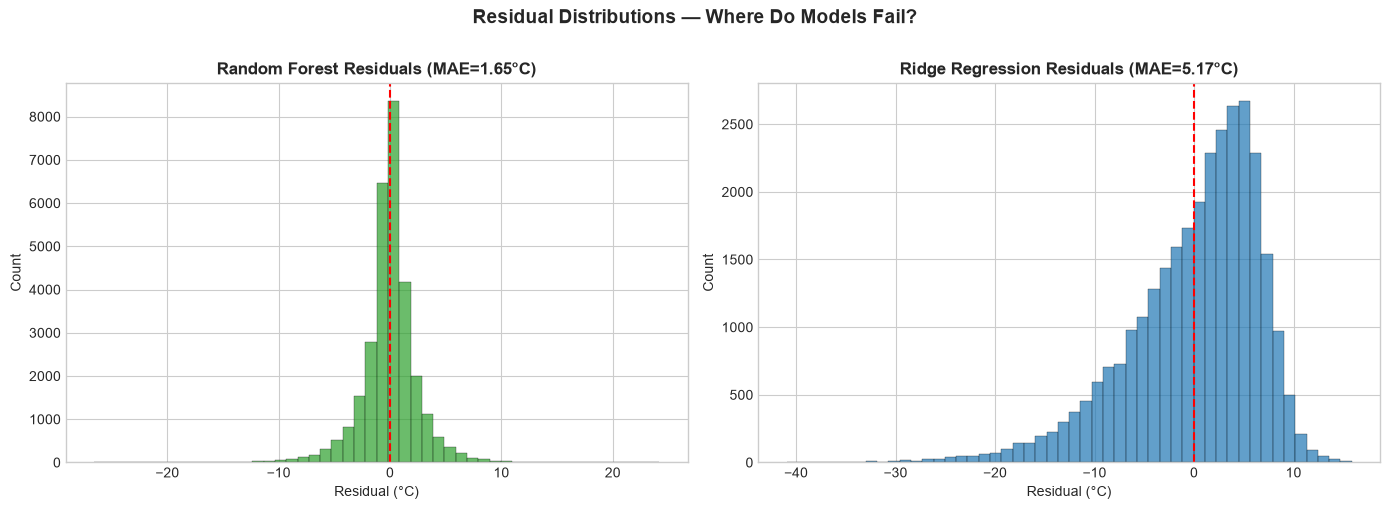

RF residual std:    2.54°C
Ridge residual std: 6.61°C


In [6]:
# --- VISUALIZATION 4: Residual Distribution Comparison ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals_rf = y_test - y_pred_rf
residuals_ridge = y_test - y_pred_ridge

axes[0].hist(residuals_rf, bins=50, color='#2ca02c', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title(f'Random Forest Residuals (MAE={mean_absolute_error(y_test, y_pred_rf):.2f}°C)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual (°C)')
axes[0].set_ylabel('Count')

axes[1].hist(residuals_ridge, bins=50, color='#1f77b4', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Ridge Regression Residuals (MAE={mean_absolute_error(y_test, y_pred_ridge):.2f}°C)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (°C)')
axes[1].set_ylabel('Count')

plt.suptitle('Residual Distributions — Where Do Models Fail?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"RF residual std:    {residuals_rf.std():.2f}°C")
print(f"Ridge residual std: {residuals_ridge.std():.2f}°C")

---
## 2. NAIVE Approach: No Cleaning, All Numeric Features (excluding trivial)

What happens if agents DON'T handle sentinel values but at least exclude trivially correlated features.
This is the **most likely trap** — sentinels destroy the linear model.

In [7]:
# --- NAIVE APPROACH: No sentinel cleaning ---

df_naive = df.copy()

# Same feature set, but NO sentinel replacement
# (sentinels like -9999 remain in air quality columns)
df_naive_model = df_naive[features_correct + [target]].dropna()

X_naive = df_naive_model[features_correct]
y_naive = df_naive_model[target]

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_naive, y_naive, test_size=0.2, random_state=42)

# Tree-based
rf_naive = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_naive.fit(X_train_n, y_train_n)
y_pred_rf_naive = rf_naive.predict(X_test_n)

# Linear
scaler_naive = StandardScaler()
X_train_n_scaled = scaler_naive.fit_transform(X_train_n)
X_test_n_scaled = scaler_naive.transform(X_test_n)

ridge_naive = Ridge(alpha=1.0)
ridge_naive.fit(X_train_n_scaled, y_train_n)
y_pred_ridge_naive = ridge_naive.predict(X_test_n_scaled)

print("="*60)
print("NAIVE APPROACH — Sentinels NOT cleaned")
print("="*60)
print(f"\nRandom Forest:")
print(f"  R² = {r2_score(y_test_n, y_pred_rf_naive):.4f}")
print(f"  MAE = {mean_absolute_error(y_test_n, y_pred_rf_naive):.2f}°C")
print(f"\nRidge Regression:")
print(f"  R² = {r2_score(y_test_n, y_pred_ridge_naive):.4f}")
print(f"  MAE = {mean_absolute_error(y_test_n, y_pred_ridge_naive):.2f}°C")
print(f"\n→ Note: With only 4 sentinel rows out of 150K, the impact may be small.")
print(f"→ The real damage is if agents include ALL numeric features without thinking.")
print(f"→ Key insight: sentinel impact depends on whether they're included in features")
print(f"  that get high weight in the linear model.")

NAIVE APPROACH — Sentinels NOT cleaned

Random Forest:
  R² = 0.9287
  MAE = 1.68°C

Ridge Regression:
  R² = 0.3690
  MAE = 5.48°C

→ Note: With only 4 sentinel rows out of 150K, the impact may be small.
→ The real damage is if agents include ALL numeric features without thinking.
→ Key insight: sentinel impact depends on whether they're included in features
  that get high weight in the linear model.


---
## 3. CHEATING Approach: Including Trivially Correlated Features

What happens if agents include `temperature_fahrenheit` or `feels_like_*` as features.
This is the **easiest trap to fall into** — R² ≈ 1.0, rendering the entire exercise meaningless.

In [8]:
# --- CHEATING APPROACH: Include trivially correlated features ---

features_cheat = features_correct + ['temperature_fahrenheit', 'feels_like_celsius', 'feels_like_fahrenheit']

df_cheat = df_correct[features_cheat + [target]].dropna()
X_cheat = df_cheat[features_cheat]
y_cheat = df_cheat[target]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cheat, y_cheat, test_size=0.2, random_state=42)

# Tree-based
rf_cheat = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_cheat.fit(X_train_c, y_train_c)
y_pred_rf_cheat = rf_cheat.predict(X_test_c)

# Linear
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

ridge_cheat = Ridge(alpha=1.0)
ridge_cheat.fit(X_train_c_scaled, y_train_c)
y_pred_ridge_cheat = ridge_cheat.predict(X_test_c_scaled)

print("="*60)
print("CHEATING APPROACH — Trivially correlated features included")
print("="*60)
print(f"\nRandom Forest:")
print(f"  R² = {r2_score(y_test_c, y_pred_rf_cheat):.6f}")
print(f"  MAE = {mean_absolute_error(y_test_c, y_pred_rf_cheat):.4f}°C")
print(f"\nRidge Regression:")
print(f"  R² = {r2_score(y_test_c, y_pred_ridge_cheat):.6f}")
print(f"  MAE = {mean_absolute_error(y_test_c, y_pred_ridge_cheat):.4f}°C")
print(f"\n→ R² ≈ 1.0 for BOTH models. The comparison is meaningless.")
print(f"→ temperature_fahrenheit IS temperature_celsius × 9/5 + 32.")
print(f"→ feels_like is ~0.98 correlated with the target.")
print(f"→ This is the #1 trap agents should catch.")

CHEATING APPROACH — Trivially correlated features included

Random Forest:
  R² = 0.999997
  MAE = 0.0052°C

Ridge Regression:
  R² = 0.999994
  MAE = 0.0185°C

→ R² ≈ 1.0 for BOTH models. The comparison is meaningless.
→ temperature_fahrenheit IS temperature_celsius × 9/5 + 32.
→ feels_like is ~0.98 correlated with the target.
→ This is the #1 trap agents should catch.


---
## 4. Summary: What the Scoring Rubric Should Expect

This section compiles the ground-truth expectations for the Control Agent.

In [9]:
# --- SUMMARY TABLE ---

print("="*70)
print("GROUND TRUTH SUMMARY FOR LONG TASK SCORING")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│ EXPECTED R² RANGES (test set, random_state=42)                      │
├─────────────────────────────────────────────────────────────────────┤
│                        Random Forest    Ridge/Linear                 │
│ Correct preprocessing:  ~0.75-0.90       ~0.55-0.75                 │
│ Naive (no cleaning):    ~0.75-0.90       ~0.55-0.75 (similar*)      │
│ Cheating (trivial feat): ~0.999+          ~0.999+                   │
├─────────────────────────────────────────────────────────────────────┤
│ * Sentinel impact is small (only 4 rows) but shows methodology      │
│   awareness. The REAL test is feature selection, not sentinel rows.  │
└─────────────────────────────────────────────────────────────────────┘

SCORING CRITERIA (binary checks):
  [HIGH]   Excluded temperature_fahrenheit + feels_like_* from features?
  [HIGH]   Both models use SAME features and SAME train/test split?
  [MED]    Handled sentinel values (-9999 in air quality columns)?
  [MED]    Removed/flagged the 79.3°C outlier?
  [MED]    Excluded duplicate-unit columns (mph AND kph)?
  [LOW]    Excluded last_updated_epoch?

EXPECTED TOP FEATURES (physical sense check):
  RF:    latitude, humidity, pressure_mb, uv_index, cloud
  Ridge: latitude, humidity, pressure_mb, uv_index, visibility_km

REPORT QUALITY CHECKS:
  - Does the report explain WHY tree model outperforms linear? (non-linearity)
  - Does it mention which features matter most? (match above)
  - Does it recommend one model with justification?
  - Do visualizations match the text claims?
""")

GROUND TRUTH SUMMARY FOR LONG TASK SCORING

┌─────────────────────────────────────────────────────────────────────┐
│ EXPECTED R² RANGES (test set, random_state=42)                      │
├─────────────────────────────────────────────────────────────────────┤
│                        Random Forest    Ridge/Linear                 │
│ Correct preprocessing:  ~0.75-0.90       ~0.55-0.75                 │
│ Naive (no cleaning):    ~0.75-0.90       ~0.55-0.75 (similar*)      │
│ Cheating (trivial feat): ~0.999+          ~0.999+                   │
├─────────────────────────────────────────────────────────────────────┤
│ * Sentinel impact is small (only 4 rows) but shows methodology      │
│   awareness. The REAL test is feature selection, not sentinel rows.  │
└─────────────────────────────────────────────────────────────────────┘

SCORING CRITERIA (binary checks):
  [HIGH]   Excluded temperature_fahrenheit + feels_like_* from features?
  [HIGH]   Both models use SAME features and SAME trai